In [2]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import netCDF4 as nc

# 1. LOAD COORDINATE LOOKUP DATA (Same as your script)
LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/ABI_EAST_GEO_TOPO_LOMSK.nc"
f_coords = nc.Dataset(LATLONDATA)
abiLong = np.array(f_coords['Longitude'])
abiLat = np.array(f_coords['Latitude'])

# Pre-calculate slices for search logic
latSlice = abiLat[:, 5424][18:-18][::-1]
longSlice = abiLong[5424, :][18:-18]

def find_abi_coords_raw(lat, lon):
    """Convert single lat/lon to absolute ABI grid coordinates with robust search"""
    if lon < 0: lon += 360
    AREA_SIZE = 1000
    
    # Initial guess based on center slices
    lati = len(latSlice) - np.searchsorted(latSlice, lat) + 17
    loni = np.searchsorted(longSlice, lon) + 18
    
    # Bound the guess to avoid index errors
    lati = np.clip(lati, AREA_SIZE, abiLat.shape[0] - AREA_SIZE)
    loni = np.clip(loni, AREA_SIZE, abiLat.shape[1] - AREA_SIZE)
    
    # Extract local window
    sub_lat = abiLat[lati-AREA_SIZE:lati+AREA_SIZE, loni-AREA_SIZE:loni+AREA_SIZE]
    sub_lon = abiLong[lati-AREA_SIZE:lati+AREA_SIZE, loni-AREA_SIZE:loni+AREA_SIZE]
    
    # Mask out -999 values
    valid_mask = (sub_lat != -999) & (sub_lon != -999)
    
    if not np.any(valid_mask):
        # FALLBACK: Global search if local search is all off-disk
        # This is slow, but better than failing
        distances = np.abs(abiLat - lat) + np.abs(abiLong - lon)
        # Mask global invalid
        distances[abiLat == -999] = np.inf
        coords = np.unravel_index(np.argmin(distances), distances.shape)
        return np.array(coords)
    
    # Local search in valid data
    distances = np.abs(sub_lat - lat) + np.abs(sub_lon - lon)
    distances[~valid_mask] = np.inf
    
    local_coords = np.unravel_index(np.argmin(distances), distances.shape)
    coords = np.array([local_coords[0] + lati - AREA_SIZE, local_coords[1] + loni - AREA_SIZE])
    return coords

# Function to open an npz file
def open_npz_file(npz_path):
    """Open an npz file and return the chip and metadata"""
    try:
        archive = np.load(npz_path, allow_pickle=True)
        chip = archive['chip']
        data = archive['data'].item()
        return chip, data
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None, None

In [3]:
# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

# Function to enhance image contrast
def enhance_contrast(data, enhancement_factor=3.0):
    """Apply contrast enhancement to an image band"""
    valid_mask = np.isfinite(data)
    valid_data = data[valid_mask]
    if len(valid_data) == 0: return np.zeros_like(data)
    
    p_low = max(0, 50 - enhancement_factor * 25)
    p_high = min(100, 50 + enhancement_factor * 25)
    vmin, vmax = np.nanpercentile(valid_data, p_low), np.nanpercentile(valid_data, p_high)
    
    if vmin == vmax: vmin -= 0.1; vmax += 0.1
    normalized = (data - vmin) / (vmax - vmin)
    return np.clip(normalized, 0, 1)


In [4]:
def visualize_all_timesteps(chip, data, rgb_bands=[0, 1, 4], 
                          enhancement=3.0, figsize=(15, 10)):
    """
    Create and display RGB composites with CloudSat transect overlay
    """
    n_times = chip.shape[0]
    CHIP_HALF_SIZE = 64
    
    # 1. CALCULATE TRANSECT PIXELS RELATIVE TO CHIP
    # The file name contains the anchor coords: yy-ddn-orbit_Y-X-idx
    # But we can also get them by transforming the middle point of the track
    track_lats = data['Latitude']
    track_lons = data['Longitude']
    
    # Find the central anchor point (where CloudSat was at index i)
    # In your script, the chip is centered at find_abi_coords(Latitude[i], Longitude[i])
    # and aux_data contains points from i+46 to i-45. 
    # So the anchor is roughly the middle of the track array.
    mid_idx = len(track_lats) // 2
    anchor_coords = find_abi_coords_raw(track_lats[mid_idx], track_lons[mid_idx])
    
    # Map all track points to relative chip coordinates
    rel_track_y = []
    rel_track_x = []
    
    for lt, ln in zip(track_lats, track_lons):
        c = find_abi_coords_raw(lt, ln)
        # Transform to 0-128 space: (abs_coord - anchor) + offset
        # Since the crop is [anchor-64 : anchor+64]
        ry = c[0] - (anchor_coords[0] - CHIP_HALF_SIZE)
        rx = c[1] - (anchor_coords[1] - CHIP_HALF_SIZE)
        rel_track_y.append(ry)
        rel_track_x.append(rx)

    # Plotting
    n_cols = 3
    n_rows = (n_times + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes_flat = [axes] if n_times == 1 else axes.flatten()
    
    for t in range(n_times):
        try:
            band_data = [chip[t, :, :, b] for b in rgb_bands]
            enhanced_bands = [enhance_contrast(band, enhancement) for band in band_data]
            rgb = np.stack(enhanced_bands, axis=-1)
            
            # Display image
            axes_flat[t].imshow(rgb, interpolation='nearest')
            
            # OVERLAY TRANSECT - ONLY ON TIMESTEP 2
            if t == 2:
                # Red line for the track, with a dot in the middle
                axes_flat[t].plot(rel_track_x, rel_track_y, color='red', linewidth=1.5, alpha=0.8, label='Track')
                axes_flat[t].scatter(rel_track_x[mid_idx], rel_track_y[mid_idx], color='yellow', s=30, edgecolors='black', zorder=5)
                axes_flat[t].set_title(f"Timestep {t} (Overpass)")
            else:
                axes_flat[t].set_title(f"Timestep {t}")
            
            axes_flat[t].axis('off')
            
        except Exception as e:
            axes_flat[t].text(0.5, 0.5, f"Error: {str(e)[:30]}", ha='center', va='center', transform=axes_flat[t].transAxes)
            axes_flat[t].axis('off')
    
    for i in range(n_times, len(axes_flat)): axes_flat[i].set_visible(False)
    plt.suptitle(f"CloudSat Track Overlay (Center: Yellow Dot)", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

In [5]:
def process_multiple_npz_files(directory_path, rgb_bands=[12, 13, 14], enhancement=3.0, max_files=3):
    npz_files = find_npz_files(directory_path)
    if not npz_files: return
    
    files_to_process = random.sample(npz_files, min(max_files, len(npz_files)))
    
    for npz_file in files_to_process:
        print(f"\nProcessing: {os.path.basename(npz_file)}")
        chip, data = open_npz_file(npz_file)
        if chip is not None:
            visualize_all_timesteps(chip, data, rgb_bands=rgb_bands, enhancement=enhancement)



Processing: 2020-001-72870_9247-7689-4540.npz


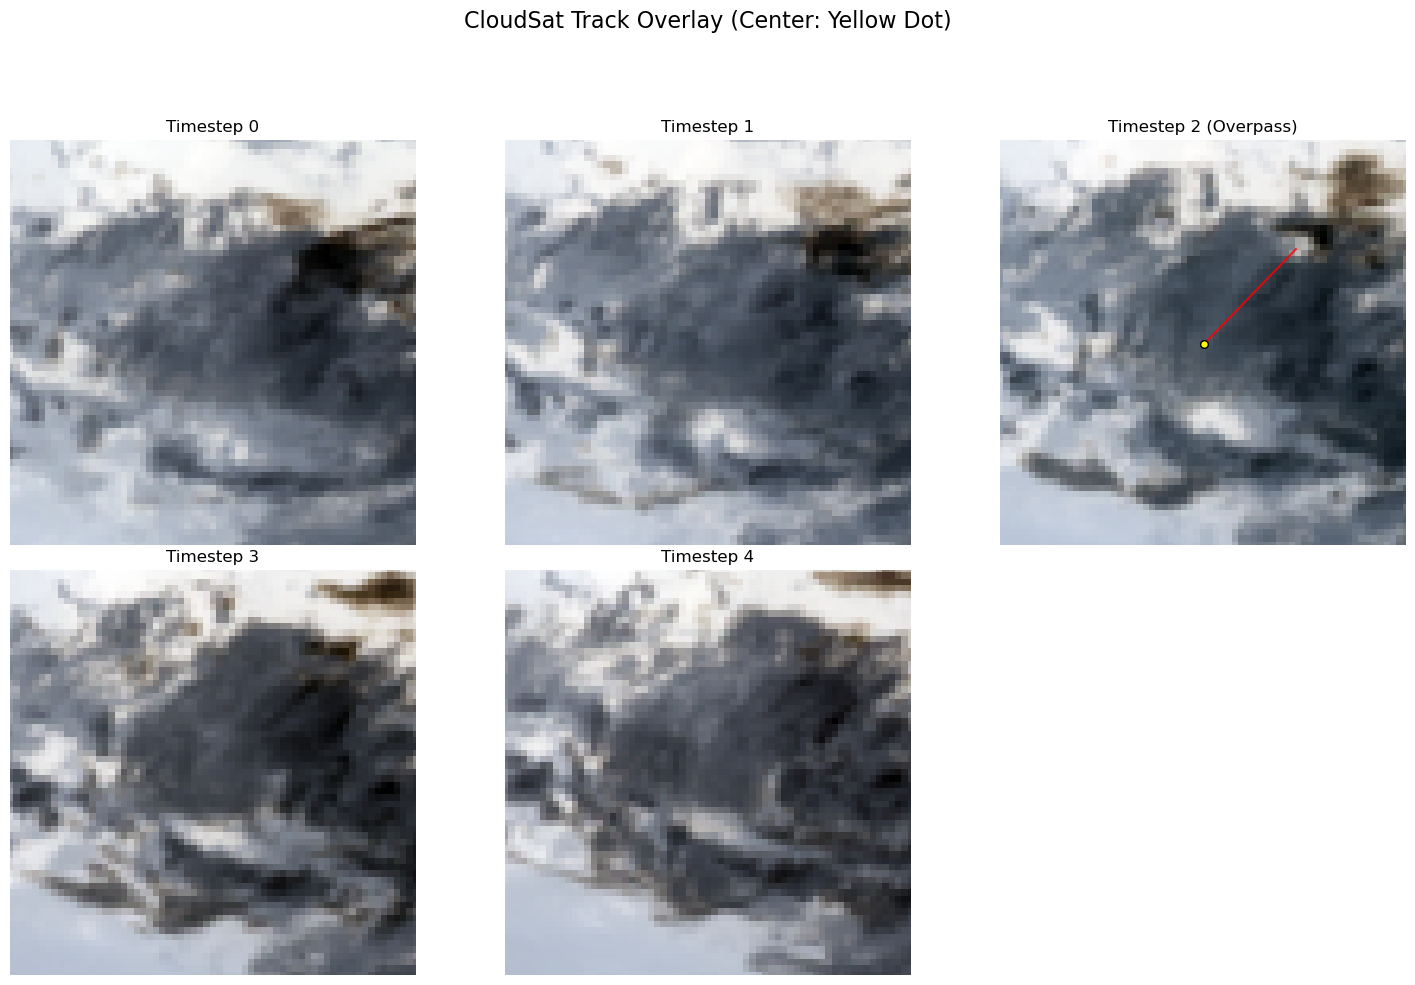


Processing: 2020-001-72866_6436-1600-990.npz


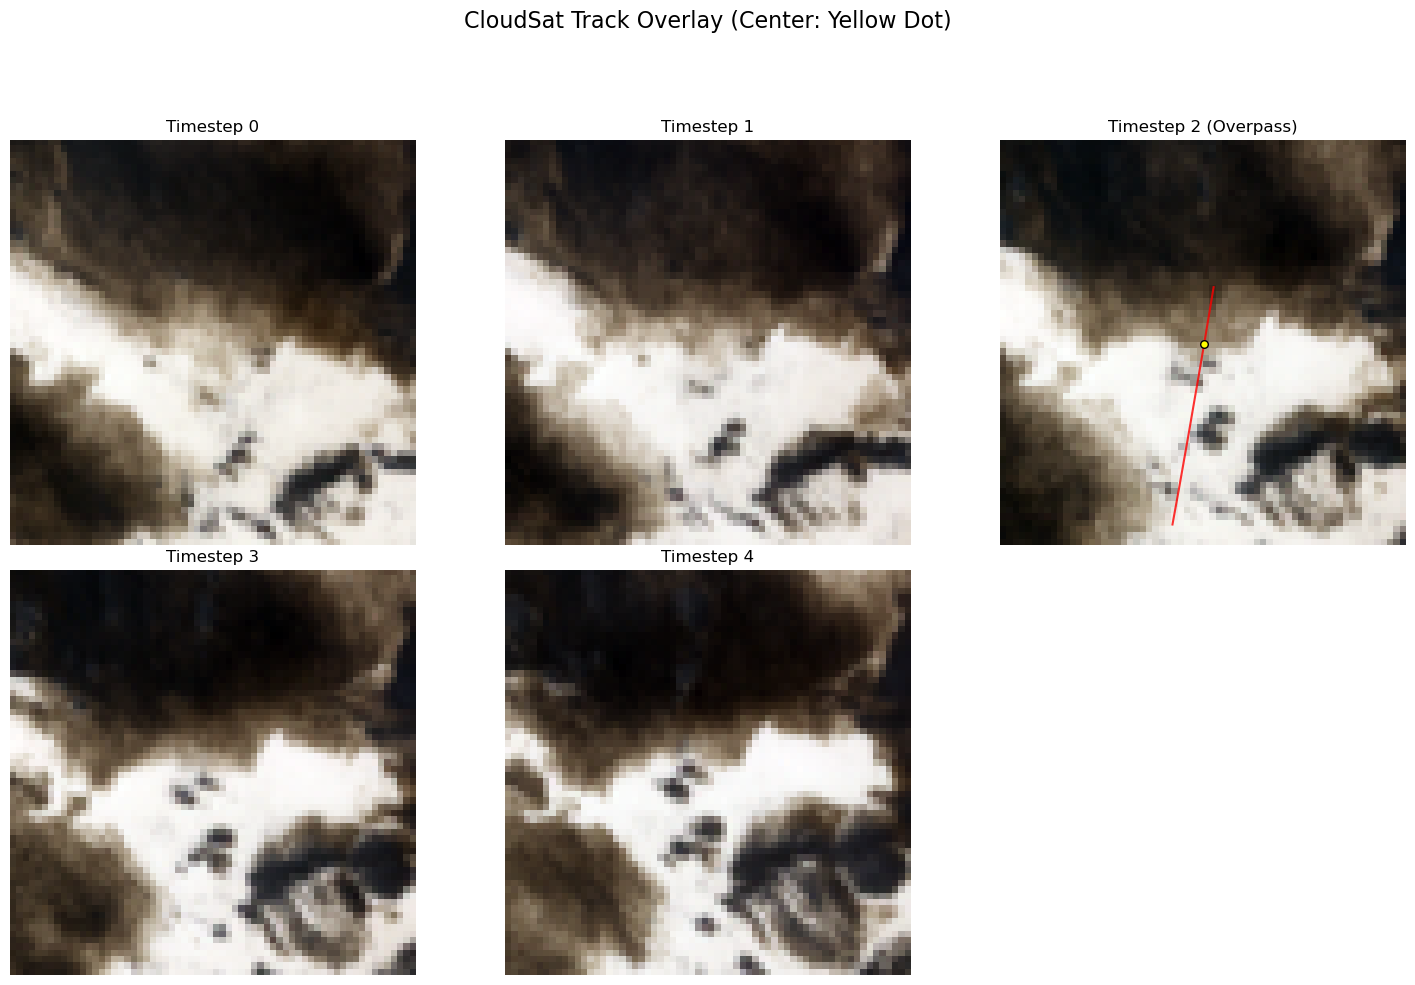


Processing: 2020-001-72864_1813-3988-14305.npz


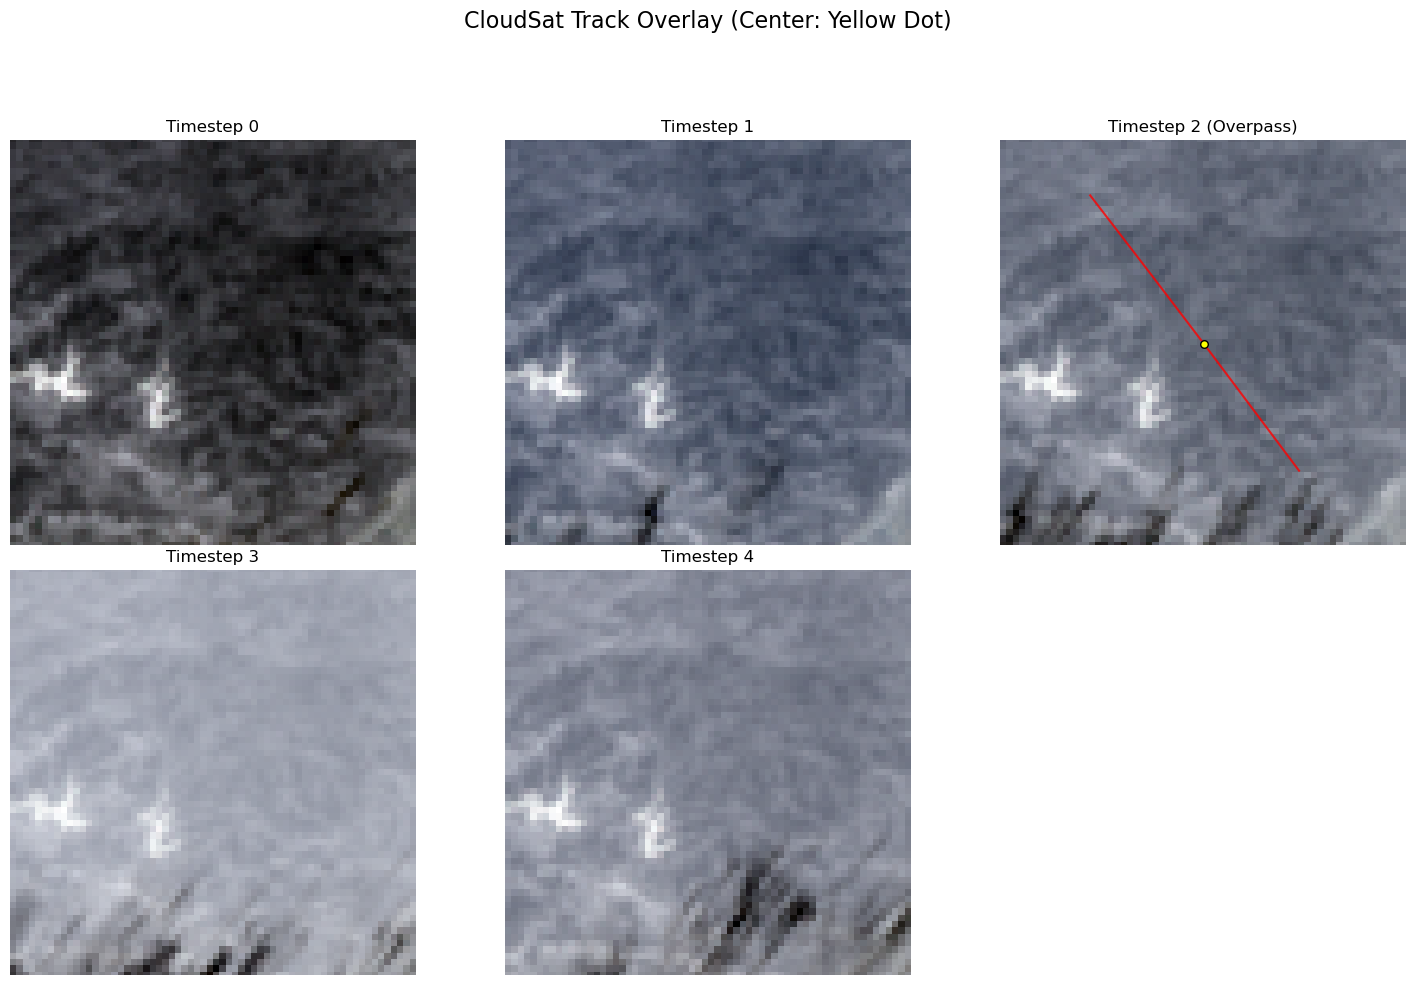


Processing: 2020-001-72865_8017-2559-2610.npz


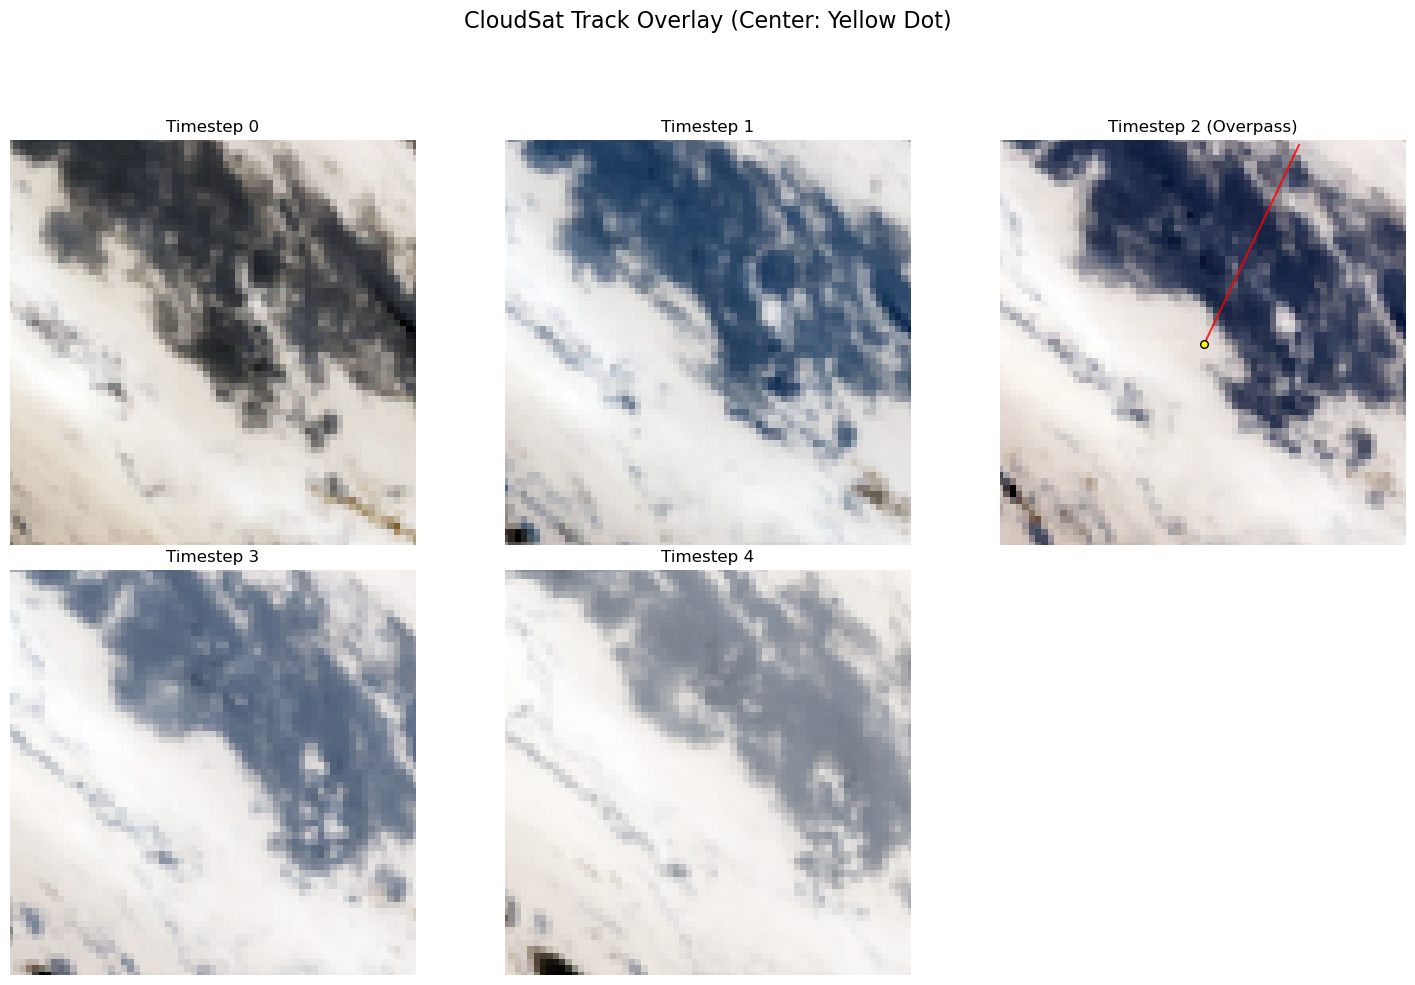


Processing: 2020-001-72865_1713-2431-14035.npz


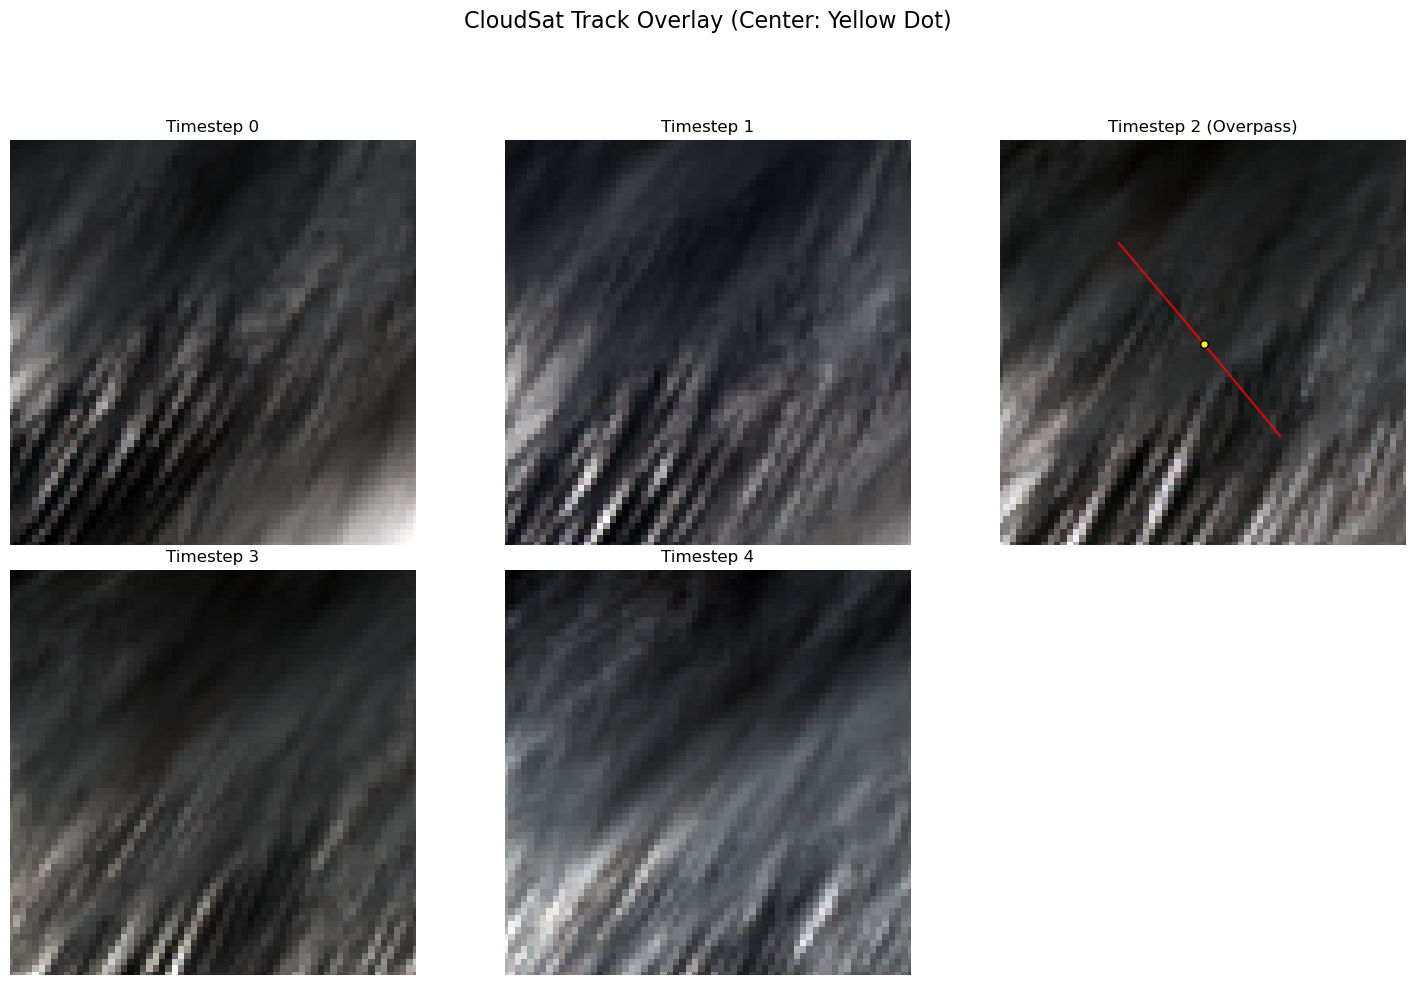


Processing: 2020-001-72866_7099-1600-1665.npz


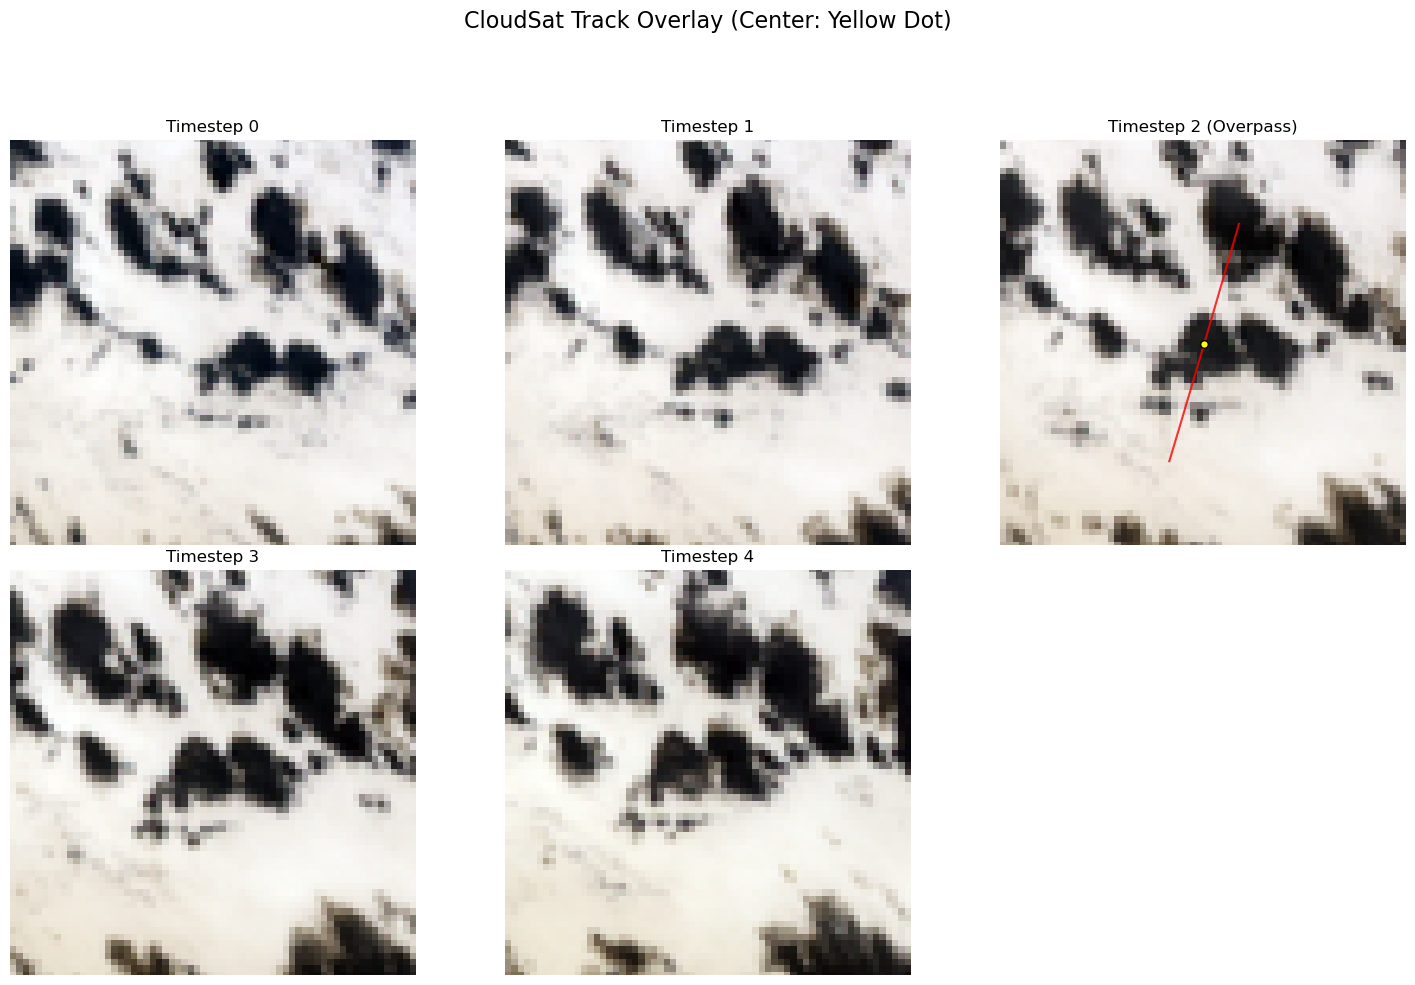


Processing: 2020-001-72868_1600-8995-13445.npz


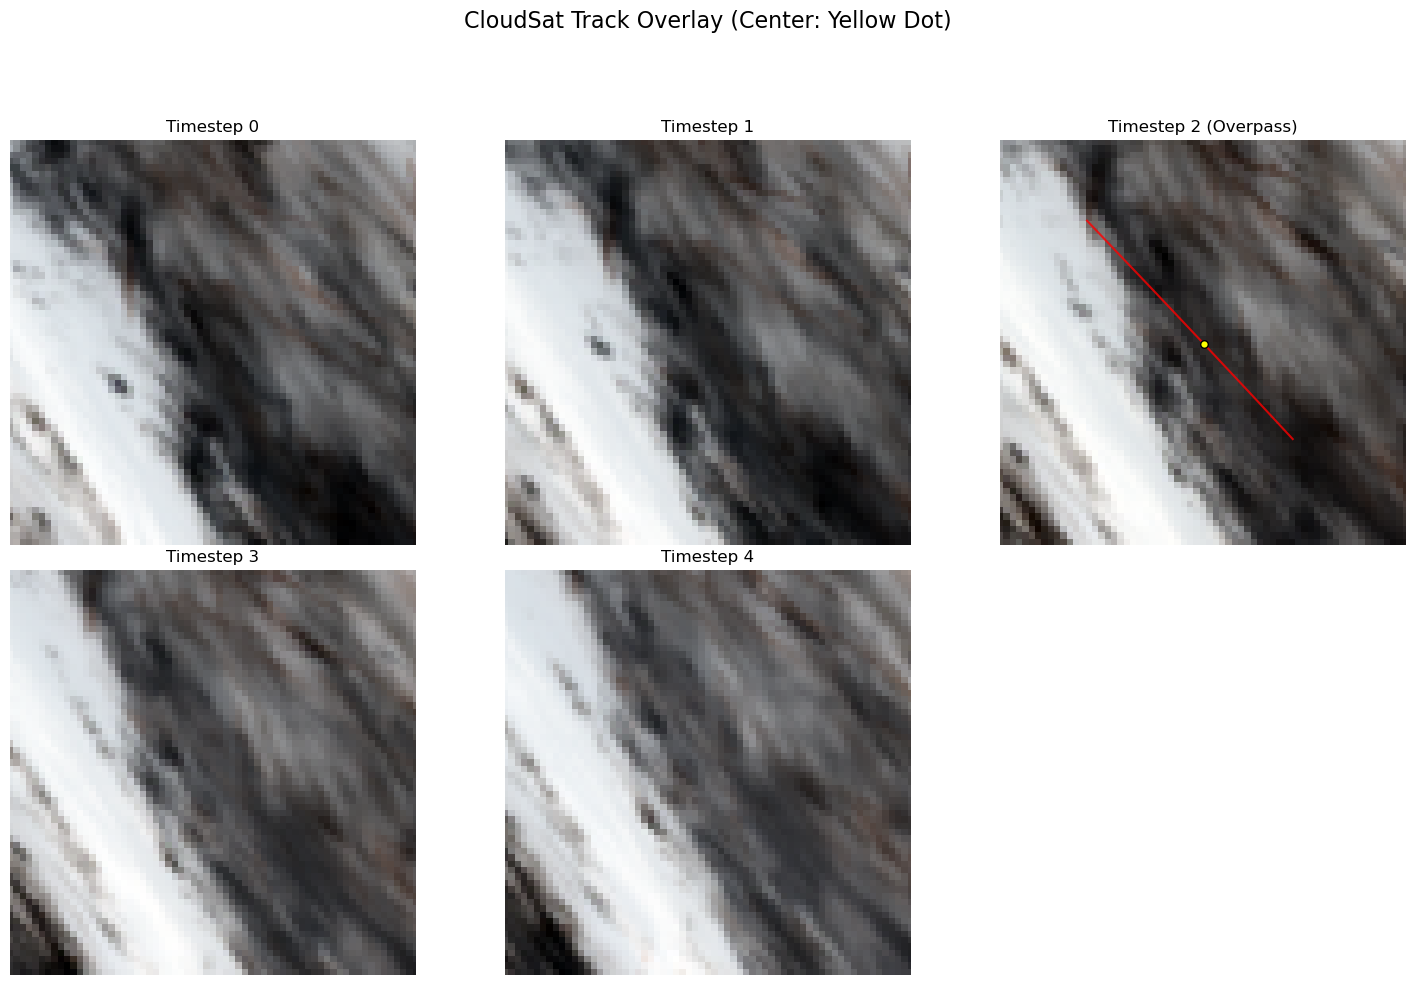


Processing: 2020-001-72865_7732-2540-2295.npz


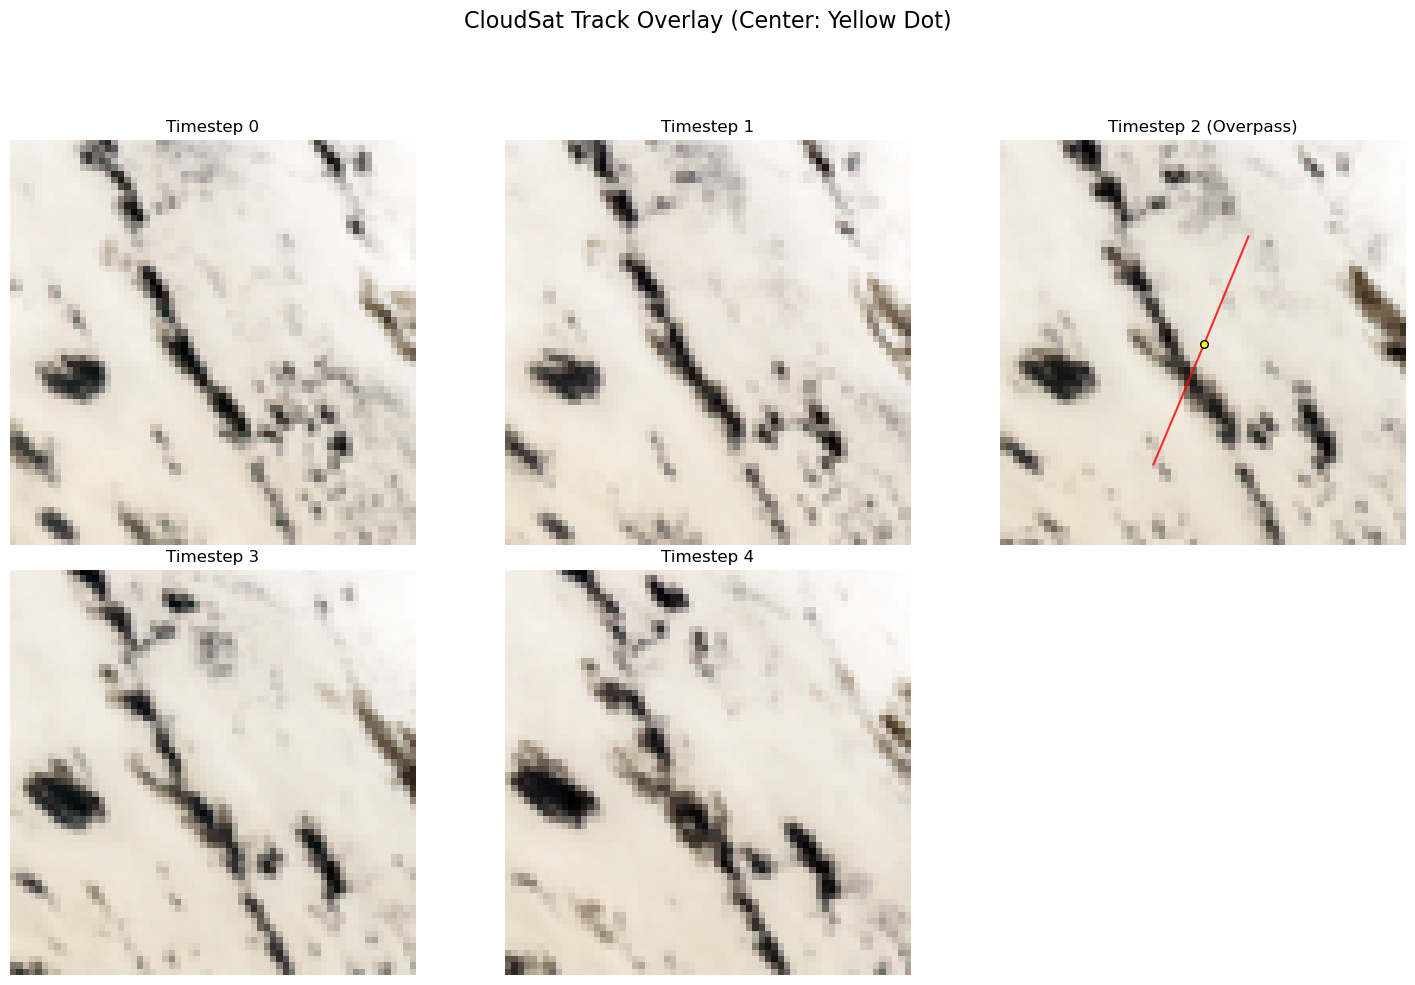


Processing: 2020-001-72866_7880-1600-2520.npz


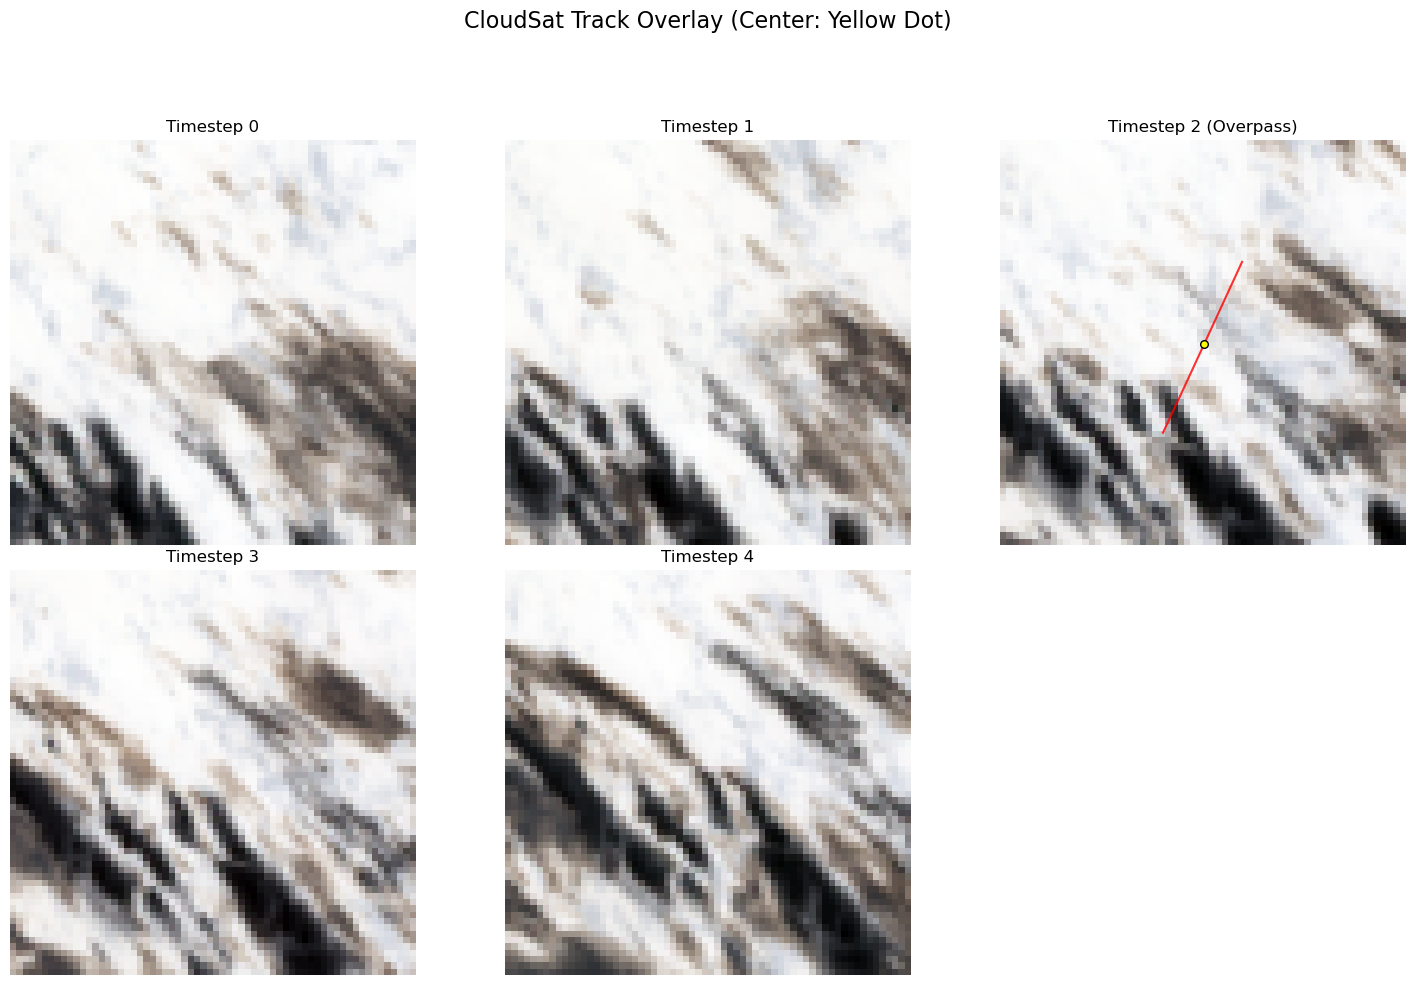


Processing: 2020-001-72866_8947-1600-3420.npz


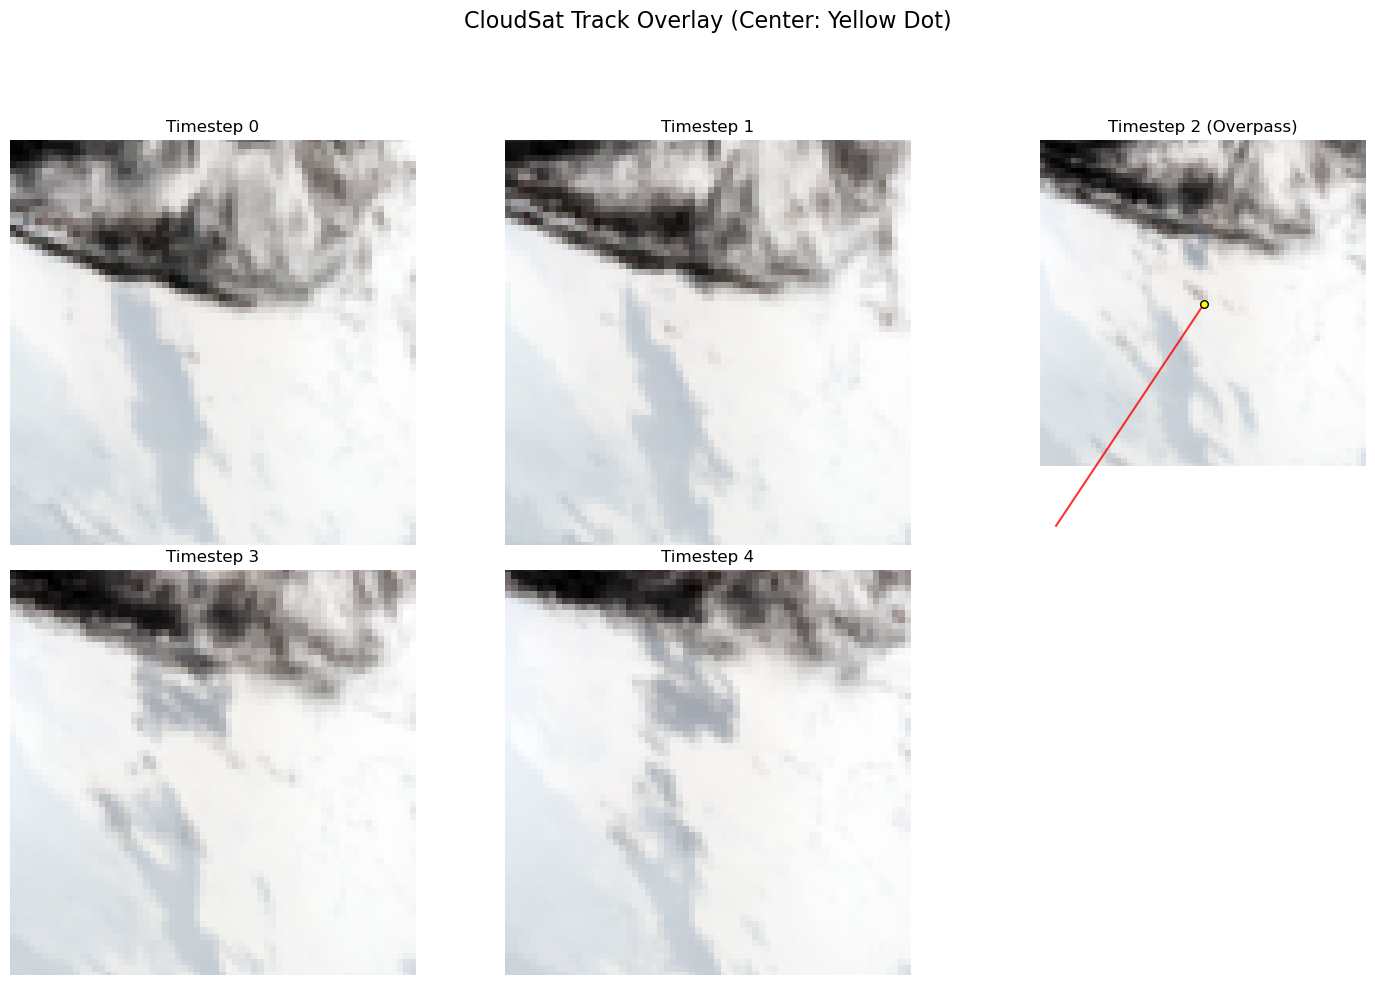

In [7]:
output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output'

process_multiple_npz_files(
    directory_path=output_directory,
    rgb_bands=[12, 13, 14], # Thermal bands
    enhancement=3.0,
    max_files=10 # Showing 1 at a time for clarity
)